# DB Scan

<center>

__Modelación del Aprendizaje con Inteligencia Artificial__

_GPO 302_

Actividad 6 _ DB Scan_


Prof. Jorge Adolfo Ramírez Uresti




Diego A. Parra Ruíz - - - A01801026
</center>

In [ ]:
pip install kneed

## Librerías

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator
from sklearn.cluster import DBSCAN
from collections import Counter
from sklearn.metrics import pairwise_distances

## Importación del Dataset

In [ ]:
df = pd.read_csv("https://reneshbedre.github.io/assets/posts/tsne/tsne_scores.csv")
print(df.head(2))

print(df.shape)
(4406, 2)

     t-SNE-1    t-SNE-2
0  10.846841 -16.712580
1  24.794334 -16.775398
(4406, 2)


(4406, 2)

## Optimización de la Distancia

In [ ]:
# n_neighbors = 5 as kneighbors function returns distance of point to itself (i.e. first column will be zeros)
nbrs = NearestNeighbors(n_neighbors = 5).fit(df)
# Find the k-neighbors of a point
neigh_dist, neigh_ind = nbrs.kneighbors(df)
# sort the neighbor distances (lengths to points) in ascending order
# axis = 0 represents sort along first axis i.e. sort along row
sort_neigh_dist = np.sort(neigh_dist, axis = 0)

### Graficación de Rodilla

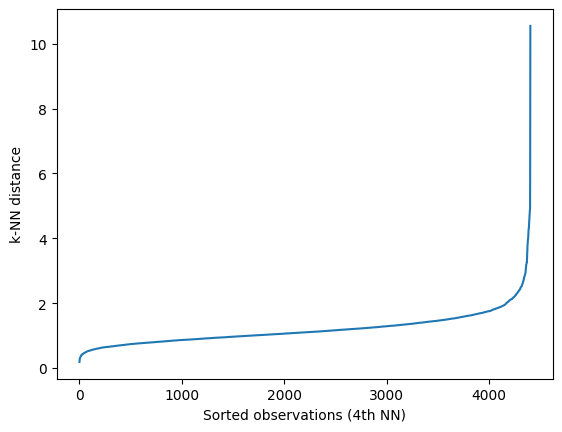

In [ ]:
k_dist = sort_neigh_dist[:, 4]
plt.plot(k_dist)
plt.ylabel("k-NN distance")
plt.xlabel("Sorted observations (4th NN)")
plt.show()

In [ ]:
kneedle = KneeLocator(x = range(1, len(neigh_dist)+1), y = k_dist, S = 1.0,
                      curve = "concave", direction = "increasing", online=True)

# get the estimate of knee point
print(kneedle.knee_y)
4.5445133515748894

4.5445133515748894


4.5445133515748894

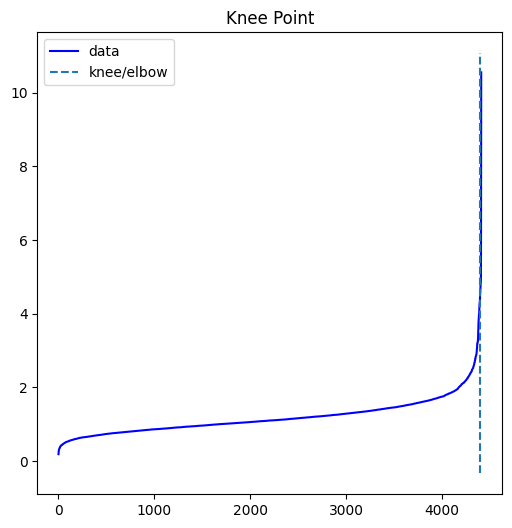

In [ ]:
kneedle.plot_knee()
plt.show()

## Creación del DB-Scan

In [ ]:
clusters = DBSCAN(eps = 4.54, min_samples = 4).fit(df)
# get cluster labels
clusters.labels_

# check unique clusters
set(clusters.labels_)
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, -1}
# -1 value represents noisy points could not assigned to any cluster

{-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}

### Contador por Clases

In [ ]:
Counter(clusters.labels_)

Counter({np.int64(0): 870,
         np.int64(1): 1524,
         np.int64(2): 769,
         np.int64(3): 301,
         np.int64(4): 153,
         np.int64(5): 246,
         np.int64(6): 232,
         np.int64(7): 283,
         np.int64(8): 11,
         np.int64(9): 6,
         np.int64(10): 8,
         np.int64(-1): 3})

### Grafiación DB-Scan

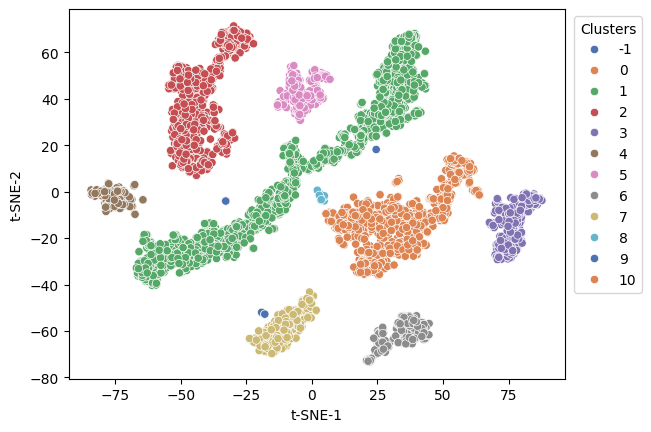

In [ ]:
p = sns.scatterplot(data = df, x = "t-SNE-1", y = "t-SNE-2", hue = clusters.labels_, legend = "full", palette = "deep")
sns.move_legend(p, "upper right", bbox_to_anchor = (1.17, 1.), title = 'Clusters')
plt.show()

## DB-Scan con nuevo EPS

In [ ]:
clusters = DBSCAN(eps = 3, min_samples = 4).fit(df)
# get cluster labels
clusters.labels_

# check unique clusters
set(clusters.labels_)
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, -1}
# -1 value represents noisy points could not assigned to any cluster

{-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}

### Contadores por Clase

In [ ]:
Counter(clusters.labels_)

Counter({np.int64(0): 836,
         np.int64(1): 1512,
         np.int64(2): 767,
         np.int64(3): 301,
         np.int64(4): 145,
         np.int64(5): 246,
         np.int64(6): 232,
         np.int64(7): 283,
         np.int64(8): 11,
         np.int64(-1): 19,
         np.int64(9): 13,
         np.int64(10): 6,
         np.int64(11): 10,
         np.int64(12): 8,
         np.int64(13): 4,
         np.int64(14): 5,
         np.int64(15): 4,
         np.int64(16): 4})

### Graficación Nuevo DB-Scan

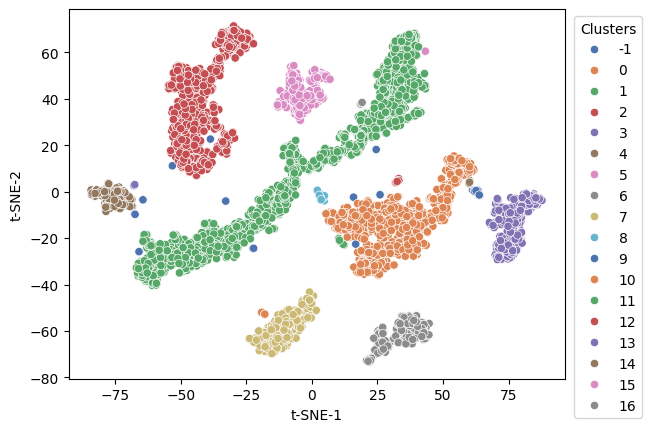

In [ ]:
p = sns.scatterplot(data = df, x = "t-SNE-1", y = "t-SNE-2", hue = clusters.labels_, legend = "full", palette = "deep")
sns.move_legend(p, "upper right", bbox_to_anchor = (1.17, 1.), title = 'Clusters')
plt.show()

## DB-Scan con Métrica Coseno

In [ ]:
clusters = DBSCAN(eps = .0001, metric = "cosine", min_samples = 4).fit(df)
# get cluster labels
clusters.labels_

# check unique clusters
set(clusters.labels_)
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, -1}
# -1 value represents noisy points could not assigned to any cluster

{-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}

## Etiquetas del DB-Scan

In [ ]:
Counter(clusters.labels_)

Counter({np.int64(0): 1332,
         np.int64(1): 6,
         np.int64(2): 894,
         np.int64(3): 23,
         np.int64(4): 641,
         np.int64(5): 173,
         np.int64(6): 234,
         np.int64(7): 641,
         np.int64(8): 7,
         np.int64(9): 286,
         np.int64(-1): 14,
         np.int64(10): 23,
         np.int64(11): 69,
         np.int64(12): 4,
         np.int64(13): 10,
         np.int64(14): 20,
         np.int64(15): 5,
         np.int64(16): 14,
         np.int64(18): 5,
         np.int64(17): 5})

### Graficación del DB-Scan

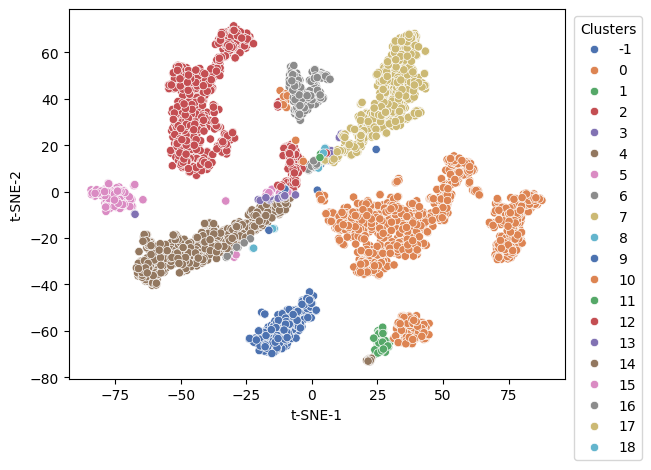

In [ ]:
p = sns.scatterplot(data = df, x = "t-SNE-1", y = "t-SNE-2", hue = clusters.labels_, legend = "full", palette = "deep")
sns.move_legend(p, "upper right", bbox_to_anchor = (1.17, 1.), title = 'Clusters')
plt.show()

## Comparación de Modelos

A partir de los modelos observados si es posible decir que el modelo más efectivo para este tipo de técnicas se basó completamente en la efectividad de la gráfica de rodilla. Esto debido a que no sobreajusta pequeños cúmulos de datos como nuevos conjuntos y les toma de una manera considerable tan solo como outliers, cosa que no se presenta en elñ segundo modelo que crea varios subconjuntos especializados con pocos puntos y que pueden representar una especificidad solo apropiada para un overfitting, mientras que el último modelo que implementó la técnica de coseno como métrica arrojó resultados algo caóticos no muy basados en propiedades de densidad, sino efectivamente en una representación de densidad no euclidiana directamente sino angular. Aunque, otro tipo de métrica que no fuese angular, tal vez manhattan podría llegar a tener más potencial de clasificación por densidad del conjunto.

Asimismo cabe mencionar que métodos de densidad más complejos son difíciles de implementar dad la reducción dimensional del dataset en cuyo proceso se pierde o se omite algún tipo de información relevante que pueda dar indicios para aportar una mejor métrica para su categorización.

Por ende es posible decir que de los 3 modelos, el modelo que utilizó una eps = 5.45 fue el modelo más apropiado para generalizar los cúmulos, supervisión y clasificación de los datos usados.